# 02 - Isolation Forest Baseline

Trains an Isolation Forest on the full cleaned CIC-IDS2017 dataset (2,520,798 rows) to detect anomalous network flows without needing attack-type labels.

**Approach:** unsupervised, trained on the full training split (both benign and anomaly rows present, but no labels used during training).

**Key result:** 47% precision / 55% recall on the ANOMALY class. Feature scaling tested and found to have no effect (Isolation Forest is scale-invariant by design). Precision-recall threshold tradeoff analyzed via `decision_function()`.

### Step 1: Load the Cleaned Dataset

In [2]:
import pandas as pd
df = pd.read_csv('/home/vboxuser/FEAR/data/cicids2017_cleaned.csv') 
print(df.shape)

(2520798, 80)


#### Separate features from labels

In [3]:
X = df.drop(columns=['Label', 'Binary_Label'])
y = df['Binary_Label']

#### Train/test split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(1764558, 78) (756240, 78)


#### Train the Isolation Forest

In [5]:
from sklearn.ensemble import IsolationForest
import time

start = time.time()
iso_forest = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)
print(f'Training took {time.time() - start:.1f} seconds')

Training took 5.4 seconds


#### Generate Predictions

In [6]:
preds = iso_forest.predict(X_test)
preds_binary = [1 if p == -1 else 0 for p in preds]

#### Evaluate

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, preds_binary))
print(classification_report(y_test, preds_binary))

[[548422  80096]
 [ 57187  70535]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89    628518
           1       0.47      0.55      0.51    127722

    accuracy                           0.82    756240
   macro avg       0.69      0.71      0.70    756240
weighted avg       0.83      0.82      0.82    756240



### Confusion matrix:

> - 548,422 correctly identified as benign (True Negatives)
> - 80,096 benign flows wrongly flagged as anomalous (False Positives)
> - 57,187 actual attacks missed (False Negatives)
> - 70,535 actual attacks correctly caught (True Positives)

#### Scale the features 

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Retrain Isolation Forest on scaled data

In [9]:
start = time.time()
iso_forest_scaled = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
iso_forest_scaled.fit(X_train_scaled)
print(f'Training took {time.time() - start:.1f} seconds')

Training took 5.4 seconds


#### Predict and evaluate

In [10]:
preds_scaled = iso_forest_scaled.predict(X_test_scaled)
preds_scaled_binary = [1 if p == -1 else 0 for p in preds_scaled]

print(confusion_matrix(y_test, preds_scaled_binary))
print(classification_report(y_test, preds_scaled_binary))

[[548031  80487]
 [ 57482  70240]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89    628518
           1       0.47      0.55      0.50    127722

    accuracy                           0.82    756240
   macro avg       0.69      0.71      0.70    756240
weighted avg       0.83      0.82      0.82    756240



*Feature scaling had negligible effect on Isolation Forest performance (precision/recall changed by <1%), consistent with its tree-based splitting mechanism being scale-invariant*

In [11]:
from sklearn.metrics import precision_recall_curve

# Get anomaly scores instead of hard predictions
scores = iso_forest.decision_function(X_test)
# Lower score = more anomalous, so we flip sign for a more intuitive "anomaly score"
anomaly_scores = -scores

precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)

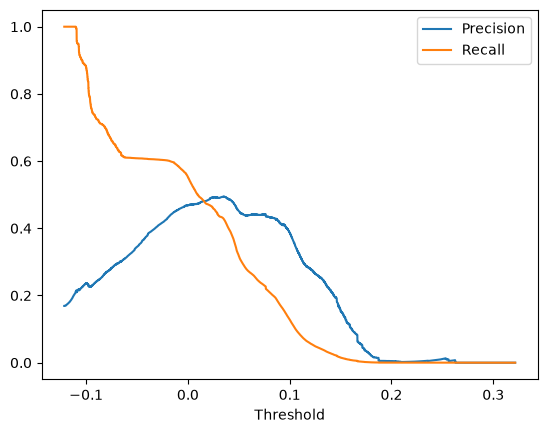

In [12]:
import matplotlib.pyplot as plt
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [13]:
original_labels_test_if = df.loc[y_test.index, 'Label']

results_if = pd.DataFrame({
    'true_label': original_labels_test_if.values,
    'predicted_anomaly': preds_binary
})

recall_by_type_if = results_if.groupby('true_label')['predicted_anomaly'].mean().sort_values()
print(recall_by_type_if)

true_label
Web Attack � Sql Injection    0.000000
FTP-Patator                   0.000552
PortScan                      0.003313
SSH-Patator                   0.012766
Web Attack � XSS              0.016043
Bot                           0.028777
Web Attack � Brute Force      0.066815
BENIGN                        0.127436
DDoS                          0.526993
DoS slowloris                 0.612005
DoS GoldenEye                 0.714471
Infiltration                  0.857143
DoS Slowhttptest              0.865095
DoS Hulk                      0.881457
Heartbleed                    1.000000
Name: predicted_anomaly, dtype: float64


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

iso_forest_smote = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
iso_forest_smote.fit(X_train_smote)

preds_smote = iso_forest_smote.predict(X_test)
preds_smote_binary = [1 if p == -1 else 0 for p in preds_smote]
print(classification_report(y_test, preds_smote_binary))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86    628518
           1       0.30      0.27      0.29    127722

    accuracy                           0.77    756240
   macro avg       0.58      0.57      0.58    756240
weighted avg       0.76      0.77      0.77    756240

